# 01 — The test sequences, and how complex they actually are

Every result in the paper rests on one assumption: that the four tiers of test
sequences really are ordered by complexity, and that "complexity" here means
*algorithmic* complexity rather than a statistical proxy.

This notebook is the evidence for that assumption. It produces the bottom panel
of **Figure 1**.

The argument is a convergence argument. Four measures that work on completely
different principles — one algorithmic, one statistical, two ordinary file
compressors — are computed over the same sequences. If they all rank the tiers
the same way, the ordering is a property of the sequences and not an artefact of
whichever measure was chosen.

**No logic lives in this notebook.** Everything is in `superarc.complexity_measures`,
so that the figure can be regenerated without opening Jupyter, and so the code
can be tested. The cells below show the numbers at each step, which is what
makes this a verification and not a picture.

In [1]:
import pandas as pd
from IPython.display import Image

from superarc.complexity_measures import (
    PUBLISHED_TIERS,
    compare_with_published,
    measures,
    plot,
    sequences_definitons,
)

pd.set_option("display.width", 120)

## The sequence pool

Four tiers. Each is a list of integer sequences written as text, exactly as they
were shown to the models.

In [2]:
pools = sequences_definitons()

pd.DataFrame(
    {"sequences": [len(pool) for pool in pools],
     "example": [pool[0] for pool in pools]},
    index=[f"tier {i}" for i in range(1, 5)],
)

,sequences,example
tier 1,40,"1, 2, 3, 4, 5, 6, 7, 8, 9"
tier 2,40,"0, 1, 1, 2, 3, 5, 8, 13"
tier 3,40,"3, 1, 4 ,1 ,5 ,9 ,2 ,6 , 5"
tier 4,33,"2, 6, 8, 5, 0, 3, 7, 4, 5, 6, 7, 8, 9, 0"


### Only three tiers are plotted, and the third point is tier 4

Two things happened to the tiers before publication, and both have to be applied
here or the figure will not match:

1. Tiers **3 and 4 were swapped** — the pool was generated with the two hardest
   tiers in the opposite order to the one the paper reports.
2. The new tier 4 was then **dropped**, leaving three levels.

So the three points plotted are tiers **1, 2 and 4** of the pool above. The same
convention appears in the time-series figures; it is `PUBLISHED_TIERS`.

In [3]:
PUBLISHED_TIERS  # zero-based indices into `pools`

(0, 1, 3)

## The four measures

| measure | what it is | sensitive to |
|---|---|---|
| **BDM** | Block Decomposition Method — an approximation to algorithmic complexity | the exact bit pattern |
| **Shannon** | entropy of the bit distribution | the *proportion* of ones and zeros |
| **zip** | mean length after zlib compression | repeated substrings |
| **lzw** | mean length after LZMA compression | repeated substrings, longer range |

BDM and Shannon are computed on the sequences rendered as ASCII bits, normalised
to a common length so the tiers are comparable. zip and lzw are the mean length
of the *compressed* form — no normalisation, because compressed length is itself
the measure.

Note that BDM here uses pybdm's default partition, **not** `PartitionRecursive`.
`superarc.table1` uses the recursive one. This panel does not, because that is
how the published numbers were produced.

In [4]:
computed = measures()

pd.DataFrame(computed, index=["complexity 1", "complexity 2", "complexity 3"]).T

,complexity 1,complexity 2,complexity 3
BDM,471.544501,494.951025,549.687040
Shannon,3.651075,3.674486,3.913377
zip,46.700000,49.000000,59.636364
lzw,118.100000,121.600000,131.151515


## Against what was published

The published version of this panel did **not** compute these numbers. They were
typed into the plotting cell as literals, copied by hand from the output of the
cells above it.

Three of the four series were copied correctly. The fourth is worth looking at.

In [5]:
compare_with_published(computed)

,measure,point,computed,printed in the paper,agrees
0,BDM,1,471.5445,471.544,True
1,BDM,2,494.9510,494.951,True
2,BDM,3,549.6870,549.678,False
3,Shannon,1,3.6511,3.650,True
4,Shannon,2,3.6745,3.670,True
5,Shannon,3,3.9134,3.910,True
6,zip,1,46.7000,46.700,True
7,zip,2,49.0000,49.000,True
8,zip,3,59.6364,59.630,True
9,lzw,1,118.1000,118.100,True


The BDM curve's third point was typed as `549.678`; computing it gives
`549.687`. Two digits transposed while copying.

On an axis running 470 to 550 that is less than one pixel, so the published
panel is not visibly wrong — but the figure now comes from the computation
rather than from a number someone retyped, which is the point of doing this at
all.

The other shortenings are just rounding, and two of them are inconsistent with
each other: `3.9134` was rounded to `3.91`, while `59.63636` was truncated to
`59.63` rather than rounded to `59.64`.

## The result

Every measure rises monotonically. They disagree about *how much* — Shannon
barely moves between tiers 1 and 2 while BDM moves clearly — but not about the
order. That disagreement is itself informative: Shannon only sees the proportion
of ones and zeros, so it is nearly blind to the structural difference between
tier 1 and tier 2, which is exactly the blindness the paper argues against.

/Users/alberto/Documents/projects/medLLM/outputs/latest/figure01-bottom.pdf
/Users/alberto/Documents/projects/medLLM/outputs/latest/figure01-bottom.svg
/Users/alberto/Documents/projects/medLLM/outputs/latest/figure01-bottom.png


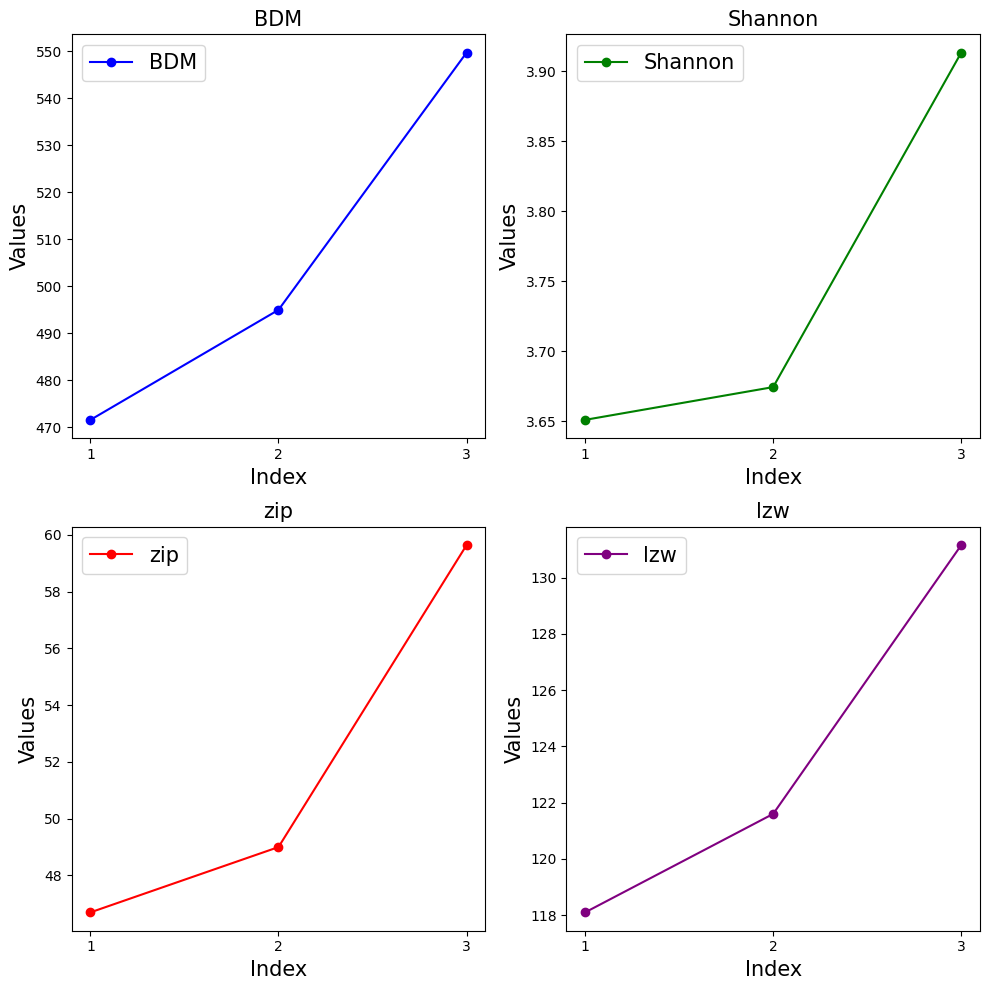

In [6]:
written = plot(computed)

for path in written:
    print(path)

# Display the file that was actually written, not a second in-memory render.
Image(filename=str(next(p for p in written if p.suffix == ".png")))

## Verification

The published figures are tracked files in `plots/` and `new_plots/`. Nothing in
this notebook writes to them — output goes to `outputs/latest/` unless
`SUPERARC_PLOTS_DIR` says otherwise — so running this cannot damage the
reference it is checked against.

This panel has no published *file*: it was drawn and discarded, so there is
nothing to compare pixel for pixel. What can be checked is the four series
against the numbers printed in the paper, which is the table above.

In [7]:
from superarc.parity import check_figures

check_figures(["figure01-bottom.png"])

,figure,status,detail
0,Fig 1 bottom BDM/Shannon/zip/lzw by complexity,newly saved,never written to disk before; no reference exists


In [8]:
# The published artifacts must be untouched by anything above.
import subprocess

dirty = subprocess.run(
    ["git", "status", "--porcelain", "new_plots/", "plots/"],
    capture_output=True, text=True,
).stdout.strip()

print(dirty if dirty else "clean: no published figure was modified")

clean: no published figure was modified
